# Drift Analysis — Statistical Reasoning

**Objective:** Determine whether ARIMA(1,1,2) has drifted on unseen 2024–2026 data using proper statistical methods, not arbitrary thresholds.

**Data sources:**
- Original walk-forward predictions (2023 test set) → `models/saved/arima_walkforward.pkl`
- Original actuals → `database/air_quality.db` → `clean_daily_my1`
- Unseen predictions (2024–2026) → `monitoring/logs/actual_vs_predicted.csv`

**Approach:**
1. Load and compare error distributions (original vs unseen)
2. Derive a statistically grounded drift threshold using 95% CI on RMSE
3. Hypothesis test: has the error distribution shifted?
4. Sequential drift detection (CUSUM)
5. Final decision rule with statistical justification

In [1]:
import sys
import os
import pickle
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from config import DB_PATH

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load Error Distributions

We have two sets of 1-step-ahead prediction errors:
- **Original (2023 test):** 90 days from Notebook 02 walk-forward
- **Unseen (2024–2026):** 778 days from the backfill pipeline

If the model hasn't drifted, these two error distributions should come from the same underlying process.

In [2]:
# --- Original walk-forward (2023 test) ---
wf_preds = pickle.load(open("../models/saved/arima_walkforward.pkl", "rb"))

conn = sqlite3.connect(DB_PATH)
clean = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"], index_col="timestamp")
conn.close()

original_actual = clean.loc[wf_preds.index, "no2"]
original_errors = original_actual - wf_preds
original_sq_errors = original_errors ** 2

# --- Unseen (2024-2026) ---
unseen = pd.read_csv("logs/actual_vs_predicted.csv", parse_dates=["date"], index_col="date")
unseen_errors = unseen["error"]
unseen_sq_errors = unseen_errors ** 2

print(f"Original test: {len(original_errors)} days ({original_errors.index.min().date()} → {original_errors.index.max().date()})")
print(f"Unseen:        {len(unseen_errors)} days ({unseen_errors.index.min().date()} → {unseen_errors.index.max().date()})")
print(f"\n{'Metric':<20} {'Original (2023)':<20} {'Unseen (2024-26)':<20}")
print(f"{'-'*60}")
print(f"{'RMSE':<20} {np.sqrt(original_sq_errors.mean()):<20.2f} {np.sqrt(unseen_sq_errors.mean()):<20.2f}")
print(f"{'MAE':<20} {np.abs(original_errors).mean():<20.2f} {np.abs(unseen_errors).mean():<20.2f}")
print(f"{'Mean Error':<20} {original_errors.mean():<20.2f} {unseen_errors.mean():<20.2f}")
print(f"{'Std Error':<20} {original_errors.std():<20.2f} {unseen_errors.std():<20.2f}")

Original test: 90 days (2023-10-02 → 2023-12-30)
Unseen:        778 days (2024-01-01 → 2026-04-02)

Metric               Original (2023)      Unseen (2024-26)    
------------------------------------------------------------
RMSE                 11.61                9.98                
MAE                  9.31                 7.82                
Mean Error           -0.74                -0.03               
Std Error            11.65                9.99                


## 2. Visualise Error Distributions

Before testing, let's see the distributions side by side. If drift has occurred, we'd expect the unseen errors to be shifted or more spread out.

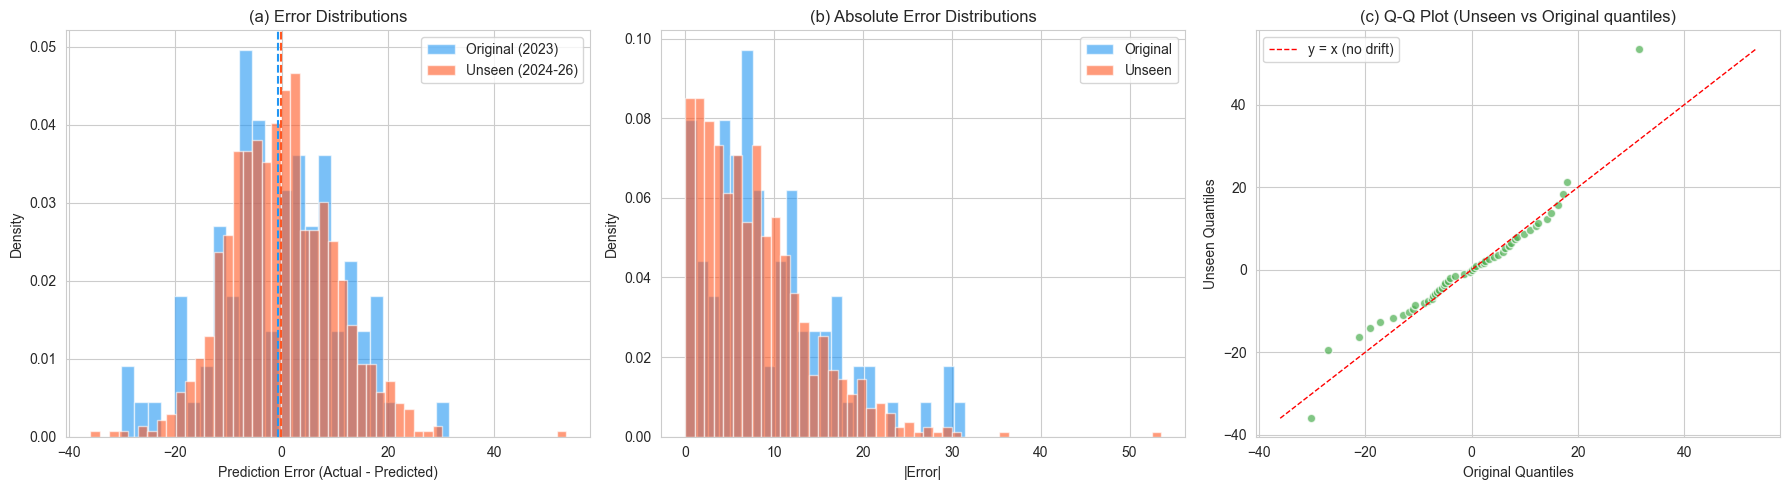

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Error distributions
axes[0].hist(original_errors, bins=25, alpha=0.6, color="#2196F3", label="Original (2023)", density=True)
axes[0].hist(unseen_errors, bins=50, alpha=0.6, color="#FF5722", label="Unseen (2024-26)", density=True)
axes[0].axvline(original_errors.mean(), color="#2196F3", linestyle="--", linewidth=1.5)
axes[0].axvline(unseen_errors.mean(), color="#FF5722", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Prediction Error (Actual - Predicted)")
axes[0].set_ylabel("Density")
axes[0].set_title("(a) Error Distributions")
axes[0].legend()

# (b) Absolute error distributions
axes[1].hist(np.abs(original_errors), bins=25, alpha=0.6, color="#2196F3", label="Original", density=True)
axes[1].hist(np.abs(unseen_errors), bins=50, alpha=0.6, color="#FF5722", label="Unseen", density=True)
axes[1].set_xlabel("|Error|")
axes[1].set_ylabel("Density")
axes[1].set_title("(b) Absolute Error Distributions")
axes[1].legend()

# (c) QQ plot — unseen errors vs original
axes[2].set_title("(c) Q-Q Plot (Unseen vs Original quantiles)")
orig_q = np.percentile(original_errors, np.linspace(0, 100, 50))
unseen_q = np.percentile(unseen_errors, np.linspace(0, 100, 50))
axes[2].scatter(orig_q, unseen_q, alpha=0.7, color="#4CAF50", edgecolors="white")
min_val = min(orig_q.min(), unseen_q.min())
max_val = max(orig_q.max(), unseen_q.max())
axes[2].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1, label="y = x (no drift)")
axes[2].set_xlabel("Original Quantiles")
axes[2].set_ylabel("Unseen Quantiles")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Confidence Interval for RMSE

The original test set gives us a baseline RMSE. But RMSE is a **point estimate** — it has sampling uncertainty. We need to know: what range of RMSE values is consistent with the original model's performance?

**Method:** Bootstrap the original test errors to build a 95% CI for RMSE. If the unseen RMSE falls within this interval, there's no evidence of drift.

Original RMSE:      11.61
95% Bootstrap CI:   [9.79, 13.31]
Unseen RMSE:        9.98

Unseen RMSE INSIDE the 95% CI


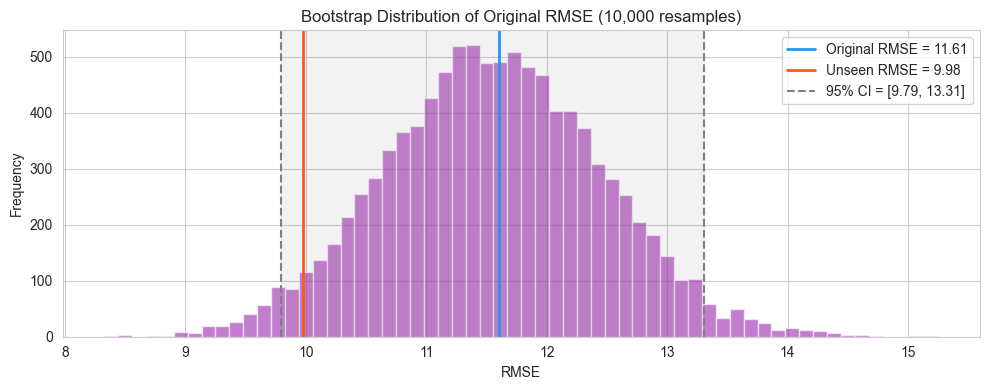

In [4]:
# Bootstrap 95% CI for the original RMSE
np.random.seed(42)
n_bootstrap = 10_000
n_original = len(original_errors)
bootstrap_rmses = []

for _ in range(n_bootstrap):
    sample = np.random.choice(original_errors.values, size=n_original, replace=True)
    bootstrap_rmses.append(np.sqrt(np.mean(sample ** 2)))

bootstrap_rmses = np.array(bootstrap_rmses)
ci_lower = np.percentile(bootstrap_rmses, 2.5)
ci_upper = np.percentile(bootstrap_rmses, 97.5)

original_rmse = np.sqrt(original_sq_errors.mean())
unseen_rmse = np.sqrt(unseen_sq_errors.mean())

print(f"Original RMSE:      {original_rmse:.2f}")
print(f"95% Bootstrap CI:   [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Unseen RMSE:        {unseen_rmse:.2f}")
print(f"\nUnseen RMSE {'INSIDE' if ci_lower <= unseen_rmse <= ci_upper else 'OUTSIDE'} the 95% CI")

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bootstrap_rmses, bins=60, alpha=0.6, color="#9C27B0", edgecolor="white")
ax.axvline(original_rmse, color="#2196F3", linewidth=2, linestyle="-", label=f"Original RMSE = {original_rmse:.2f}")
ax.axvline(unseen_rmse, color="#FF5722", linewidth=2, linestyle="-", label=f"Unseen RMSE = {unseen_rmse:.2f}")
ax.axvline(ci_lower, color="grey", linewidth=1.5, linestyle="--", label=f"95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")
ax.axvline(ci_upper, color="grey", linewidth=1.5, linestyle="--")
ax.axvspan(ci_lower, ci_upper, alpha=0.1, color="grey")
ax.set_xlabel("RMSE")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of Original RMSE (10,000 resamples)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hypothesis Tests

We test two aspects of drift:

### 4a. Has the mean squared error changed? (Welch's t-test)
- **H₀:** The mean squared error of unseen predictions = mean squared error of original predictions
- **H₁:** They differ
- Welch's t-test (unequal variances, unequal sample sizes)

### 4b. Has the error distribution shape changed? (Kolmogorov-Smirnov test)
- **H₀:** Both error samples come from the same distribution
- **H₁:** They come from different distributions
- KS test is non-parametric — sensitive to any distributional change (location, spread, shape)

In [5]:
# 4a. Welch's t-test on squared errors
t_stat, p_welch = stats.ttest_ind(unseen_sq_errors, original_sq_errors, equal_var=False)

print("=== Welch's t-test (squared errors) ===")
print(f"  Original mean SE:  {original_sq_errors.mean():.2f}")
print(f"  Unseen mean SE:    {unseen_sq_errors.mean():.2f}")
print(f"  t-statistic:       {t_stat:.3f}")
print(f"  p-value:           {p_welch:.4f}")
print(f"  Reject H₀ at α=0.05? {'YES — drift detected' if p_welch < 0.05 else 'NO — no evidence of drift'}")

print()

# 4b. Kolmogorov-Smirnov test on raw errors
ks_stat, p_ks = stats.ks_2samp(original_errors.values, unseen_errors.values)

print("=== Kolmogorov-Smirnov test (raw errors) ===")
print(f"  KS statistic:      {ks_stat:.3f}")
print(f"  p-value:           {p_ks:.4f}")
print(f"  Reject H₀ at α=0.05? {'YES — distributions differ' if p_ks < 0.05 else 'NO — no evidence distributions differ'}")

print()

# 4c. Levene's test — has the error variance changed?
lev_stat, p_lev = stats.levene(original_errors.values, unseen_errors.values)

print("=== Levene's test (error variance) ===")
print(f"  Original std:      {original_errors.std():.2f}")
print(f"  Unseen std:        {unseen_errors.std():.2f}")
print(f"  Levene statistic:  {lev_stat:.3f}")
print(f"  p-value:           {p_lev:.4f}")
print(f"  Reject H₀ at α=0.05? {'YES — variance changed' if p_lev < 0.05 else 'NO — variance stable'}")

=== Welch's t-test (squared errors) ===
  Original mean SE:  134.70
  Unseen mean SE:    99.57
  t-statistic:       -1.633
  p-value:           0.1055
  Reject H₀ at α=0.05? NO — no evidence of drift

=== Kolmogorov-Smirnov test (raw errors) ===
  KS statistic:      0.080
  p-value:           0.6497
  Reject H₀ at α=0.05? NO — no evidence distributions differ

=== Levene's test (error variance) ===
  Original std:      11.65
  Unseen std:        9.99
  Levene statistic:  4.540
  p-value:           0.0334
  Reject H₀ at α=0.05? YES — variance changed


## 5. Sequential Drift Detection — CUSUM

The tests above compare the two periods as a whole. But drift might happen **gradually**. CUSUM (Cumulative Sum) detects when the mean of a process shifts over time.

**Setup:**
- Target = mean absolute error from the original test set
- At each unseen day, accumulate the deviation from that target
- If CUSUM exceeds a threshold (derived from the original error distribution), flag that point as drift

Target MAE (from original): 9.31
Target Std:                 6.97
Allowance (k):              3.48
Decision interval (h):      27.87

Upward CUSUM exceedances:   22 days
Downward CUSUM exceedances: 38 days


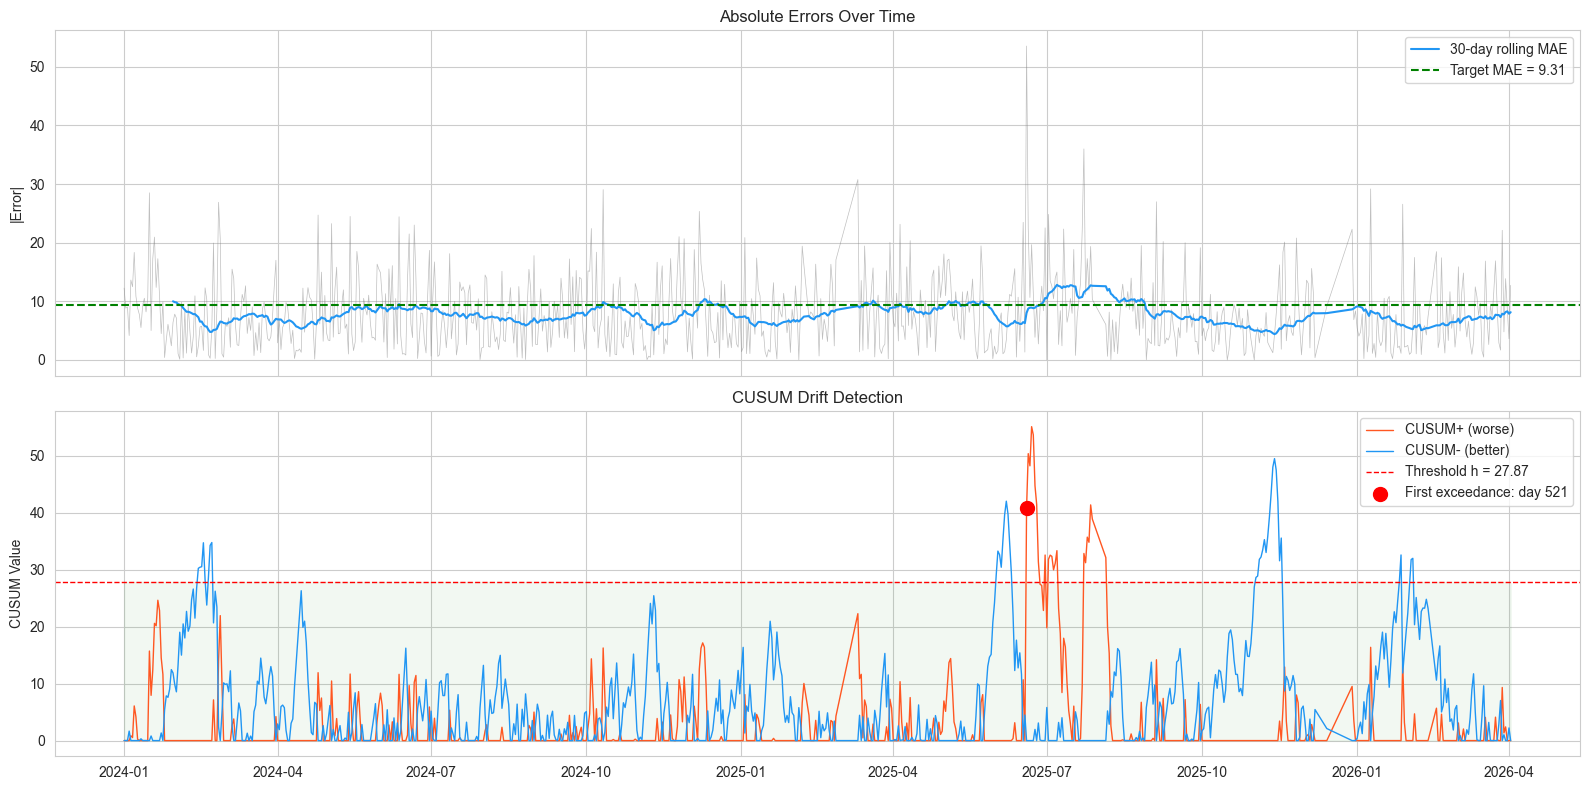

In [6]:
# CUSUM on absolute errors
target_mae = np.abs(original_errors).mean()
target_std = np.abs(original_errors).std()

# Threshold: 4 sigma (common choice for CUSUM control limit)
# Derived from original error distribution, not arbitrary
threshold = 4 * target_std * np.sqrt(len(unseen_errors))
# Normalised per-step threshold (more interpretable)
step_threshold = 4 * target_std

unseen_abs = np.abs(unseen_errors.values)
cusum_pos = np.zeros(len(unseen_abs))  # detects upward shift (worse errors)
cusum_neg = np.zeros(len(unseen_abs))  # detects downward shift (better errors)

# Allowance (slack) = 0.5 * shift we want to detect
# We want to detect a 1-sigma shift in MAE
allowance = 0.5 * target_std

for i in range(1, len(unseen_abs)):
    cusum_pos[i] = max(0, cusum_pos[i-1] + (unseen_abs[i] - target_mae) - allowance)
    cusum_neg[i] = max(0, cusum_neg[i-1] - (unseen_abs[i] - target_mae) - allowance)

# Decision interval (h) — 4 sigma is standard for ARL ~168
h = 4 * target_std

drift_points_pos = np.where(cusum_pos > h)[0]
drift_points_neg = np.where(cusum_neg > h)[0]

print(f"Target MAE (from original): {target_mae:.2f}")
print(f"Target Std:                 {target_std:.2f}")
print(f"Allowance (k):              {allowance:.2f}")
print(f"Decision interval (h):      {h:.2f}")
print(f"\nUpward CUSUM exceedances:   {len(drift_points_pos)} days")
print(f"Downward CUSUM exceedances: {len(drift_points_neg)} days")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(unseen.index, unseen_abs, alpha=0.5, linewidth=0.5, color="grey")
axes[0].plot(unseen.index, pd.Series(unseen_abs).rolling(30).mean(), color="#2196F3", linewidth=1.5, label="30-day rolling MAE")
axes[0].axhline(target_mae, color="green", linestyle="--", label=f"Target MAE = {target_mae:.2f}")
axes[0].set_ylabel("|Error|")
axes[0].set_title("Absolute Errors Over Time")
axes[0].legend()

axes[1].plot(unseen.index, cusum_pos, color="#FF5722", linewidth=1, label="CUSUM+ (worse)")
axes[1].plot(unseen.index, cusum_neg, color="#2196F3", linewidth=1, label="CUSUM- (better)")
axes[1].axhline(h, color="red", linestyle="--", linewidth=1, label=f"Threshold h = {h:.2f}")
axes[1].fill_between(unseen.index, 0, h, alpha=0.05, color="green")
if len(drift_points_pos) > 0:
    axes[1].scatter(unseen.index[drift_points_pos[0]], cusum_pos[drift_points_pos[0]],
                    color="red", s=100, zorder=5, label=f"First exceedance: day {drift_points_pos[0]}")
axes[1].set_ylabel("CUSUM Value")
axes[1].set_title("CUSUM Drift Detection")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Quarterly Rolling Analysis

Drift can be seasonal. Let's compute RMSE per quarter with the bootstrap CI overlaid to see if any quarter statistically exceeds the baseline.

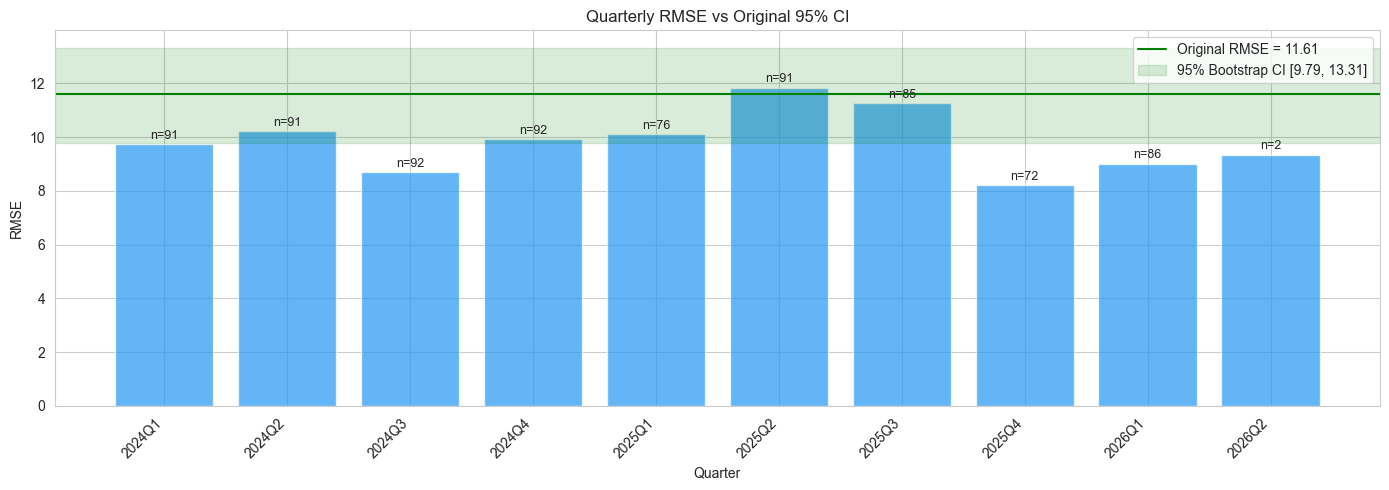


Quarter      RMSE       MAE        Days     Status
------------------------------------------------
2024Q1       9.73       7.76       91       BELOW CI (better)
2024Q2       10.23      8.06       91       WITHIN CI
2024Q3       8.69       7.22       92       BELOW CI (better)
2024Q4       9.94       7.72       92       WITHIN CI
2025Q1       10.10      7.98       76       WITHIN CI
2025Q2       11.84      9.15       91       WITHIN CI
2025Q3       11.26      8.97       85       WITHIN CI
2025Q4       8.20       6.55       72       BELOW CI (better)
2026Q1       9.02       6.77       86       BELOW CI (better)
2026Q2       9.35       8.16       2        BELOW CI (better)


In [7]:
# Quarterly RMSE with CI bands
unseen_copy = unseen.copy()
unseen_copy["quarter"] = unseen_copy.index.to_period("Q")

quarterly = unseen_copy.groupby("quarter").agg(
    rmse=("error", lambda x: np.sqrt((x**2).mean())),
    mae=("abs_error", "mean"),
    count=("actual", "count"),
)

fig, ax = plt.subplots(figsize=(14, 5))

quarters = [str(q) for q in quarterly.index]
rmses = quarterly["rmse"].values

ax.bar(quarters, rmses, color="#2196F3", alpha=0.7, edgecolor="white")
ax.axhline(original_rmse, color="green", linestyle="-", linewidth=1.5, label=f"Original RMSE = {original_rmse:.2f}")
ax.axhspan(ci_lower, ci_upper, alpha=0.15, color="green", label=f"95% Bootstrap CI [{ci_lower:.2f}, {ci_upper:.2f}]")

# Annotate counts
for i, (q, row) in enumerate(quarterly.iterrows()):
    ax.text(i, row["rmse"] + 0.2, f"n={int(row['count'])}", ha="center", fontsize=9)
    if row["rmse"] > ci_upper:
        ax.bar(i, row["rmse"], color="#F44336", alpha=0.7, edgecolor="white")

ax.set_xlabel("Quarter")
ax.set_ylabel("RMSE")
ax.set_title("Quarterly RMSE vs Original 95% CI")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Quarter':<12} {'RMSE':<10} {'MAE':<10} {'Days':<8} {'Status'}")
print(f"{'-'*48}")
for idx, row in quarterly.iterrows():
    if row["rmse"] > ci_upper:
        status = "OUTSIDE CI"
    elif row["rmse"] < ci_lower:
        status = "BELOW CI (better)"
    else:
        status = "WITHIN CI"
    print(f"{str(idx):<12} {row['rmse']:<10.2f} {row['mae']:<10.2f} {int(row['count']):<8} {status}")

## 7. Summary & Decision Rule

Bringing all the statistical evidence together into a single drift decision framework.

In [8]:
# Summary of all tests
print("=" * 65)
print("DRIFT ANALYSIS SUMMARY")
print("=" * 65)

print(f"\n{'Test':<35} {'Result':<15} {'Drift?'}")
print(f"{'-'*65}")

# 1. Bootstrap CI
ci_result = "INSIDE" if ci_lower <= unseen_rmse <= ci_upper else "OUTSIDE"
ci_drift = "NO" if ci_result == "INSIDE" else "YES"
print(f"{'Bootstrap 95% CI on RMSE':<35} {ci_result:<15} {ci_drift}")

# 2. Welch t-test
welch_drift = "YES" if p_welch < 0.05 else "NO"
print(f"{'Welch t-test (squared errors)':<35} {'p=' + f'{p_welch:.4f}':<15} {welch_drift}")

# 3. KS test
ks_drift = "YES" if p_ks < 0.05 else "NO"
print(f"{'KS test (error distribution)':<35} {'p=' + f'{p_ks:.4f}':<15} {ks_drift}")

# 4. Levene's test
lev_drift = "YES" if p_lev < 0.05 else "NO"
print(f"{'Levene test (error variance)':<35} {'p=' + f'{p_lev:.4f}':<15} {lev_drift}")

# 5. CUSUM
cusum_drift = "YES" if len(drift_points_pos) > 0 else "NO"
print(f"{'CUSUM (sequential detection)':<35} {f'{len(drift_points_pos)} exceedances':<15} {cusum_drift}")

# Overall decision — majority vote
tests = [ci_drift, welch_drift, ks_drift, lev_drift, cusum_drift]
drift_count = sum(1 for t in tests if t == "YES")

print(f"\n{'='*65}")
print(f"Tests indicating drift: {drift_count}/5")

if drift_count >= 3:
    print("VERDICT: MODEL DRIFT DETECTED — retrain recommended")
elif drift_count >= 2:
    print("VERDICT: INCONCLUSIVE — monitor closely, consider retraining")
else:
    print("VERDICT: NO SIGNIFICANT DRIFT — model is performing well")
print(f"{'='*65}")

# Derived threshold for backfill_and_evaluate.py
print(f"\n--- Statistically derived threshold for pipeline ---")
print(f"Bootstrap 95% CI upper bound: {ci_upper:.2f}")
print(f"This replaces the arbitrary 30% threshold (was {original_rmse * 1.3:.2f})")
print(f"Drift rule: flag if unseen RMSE > {ci_upper:.2f}")

DRIFT ANALYSIS SUMMARY

Test                                Result          Drift?
-----------------------------------------------------------------
Bootstrap 95% CI on RMSE            INSIDE          NO
Welch t-test (squared errors)       p=0.1055        NO
KS test (error distribution)        p=0.6497        NO
Levene test (error variance)        p=0.0334        YES
CUSUM (sequential detection)        22 exceedances  YES

Tests indicating drift: 2/5
VERDICT: INCONCLUSIVE — monitor closely, consider retraining

--- Statistically derived threshold for pipeline ---
Bootstrap 95% CI upper bound: 13.31
This replaces the arbitrary 30% threshold (was 15.09)
Drift rule: flag if unseen RMSE > 13.31
